In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as stats

import xtrack as xt
import xpart as xp
import xplt


import crystal_extraction.plotters as plotters
import crystal_extraction.utils as utils
from crystal_extraction.xsuite_line_creation import create_xsuite_line
#from crystal_extraction.crystal_extraction import CrystalExtraction
from crystal_extraction.dummy_crystal import DummyCrystal
from crystal_extraction.steinbach import Steinbach, BeamArgs, SteinArgs, sps_crystal

plotters.my_mpl_style()


In [3]:
import pickle
import typing as t

import matplotlib.pyplot as plt
import numpy as np
import requests
import xobjects as xo
import xpart as xp
import xtrack as xt
import xcoll as xc
from cpymad.madx import Madx

%matplotlib widget

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import minimize
import itertools
from shapely.geometry import Polygon
import re
import os
import pickle
from cpymad.madx import Madx
import distutils

import warnings
from IPython.display import display, HTML, Markdown, clear_output

display(HTML("<style>.rendered_html { font-size: 17px; }</style>"))
display(HTML("<style>.container { width:90% !important; }</style>"))

def printmd(string):
    display(Markdown(string))
# warnings.filterwarnings('ignore')



plt.ion()

p = 400.0  # beam momentum (GeV/c)
momentum = p  # beam momentum (GeV/c)
Brho = p * 3.3356  # beam rigidity ???

N_EX = 10e-6
N_EY = 5e-6
DPP = 1e-4


In [4]:
# Proton mass in GeV/c^2
proton_mass_GeV = xt.PROTON_MASS_EV * 1e-9

# Beam energy in GeV
beam_energy_GeV = 400

# Compute gamma
gamma = beam_energy_GeV / proton_mass_GeV
print(f"Gamma: {gamma}")

Gamma: 426.3155693395322


In [5]:
EX = N_EX / gamma
print(f"EX: {EX}")

EX: 2.3456802235706435e-08


In [6]:
deltaP_P = 1e-3
print(f"deltaP_P: {deltaP_P}")

deltaP_P: 0.001


 ### Uploading sequence

In [7]:
line = xt.Line.from_json("../database/lhc_q22.json")


# REFERENCE PARTICLE
line.particle_ref = xt.Particles(p0c=400e9, mass0=xt.PROTON_MASS_EV)

# INSERTING MARKERS
line.insert_element(name='zs21633.entry.p1mm', element=xt.Marker(), at_s=line.get_table()['s', 'ap.up.zs21633']+1e-3)
line.insert_element("tpst.21760_entry", xt.Marker(), at_s = 1712.2203)
line.insert_element("TECA.entry", xt.Marker(), at_s = 4020.8939)
line.insert_element("tcsm.51932.", xt.Marker(), at_s = 5219.6766)




#septa_names_with_apertures = install_septa(line, install_zs=True)
#line.cycle("bpcn.20902", inplace=True)


Loading line from dict:   0%|          | 0/4598 [00:00<?, ?it/s]

Done loading line from dict.           


Slicing line:   0%|          | 0/4598 [00:00<?, ?it/s]

Slicing line:   0%|          | 0/4601 [00:00<?, ?it/s]

## Twiss inspection

In [8]:
tw_init = line.twiss(method='4d')

TwissTable: 4605 rows, 62 cols
name                   s             x            px             y            py          zeta ...
sps$start              0             0             0             0             0             0
begi.10010             0             0             0             0             0             0
qf.10010               0             0             0             0             0             0
drift_0            3.085             0             0             0             0             0
mba.10030        3.44499             0             0             0             0             0
drift_1          9.70501  -2.51534e-16  -8.10998e-17             0             0  -3.87468e-14
mba.10050         10.105  -2.83972e-16  -8.10998e-17             0             0  -3.87468e-14
drift_2           16.365  -1.04083e-15  -1.61769e-16             0             0  -7.74936e-14
mbb.10070         16.755  -1.10392e-15  -1.61769e-16             0             0  -7.74936e-14
drift_3        

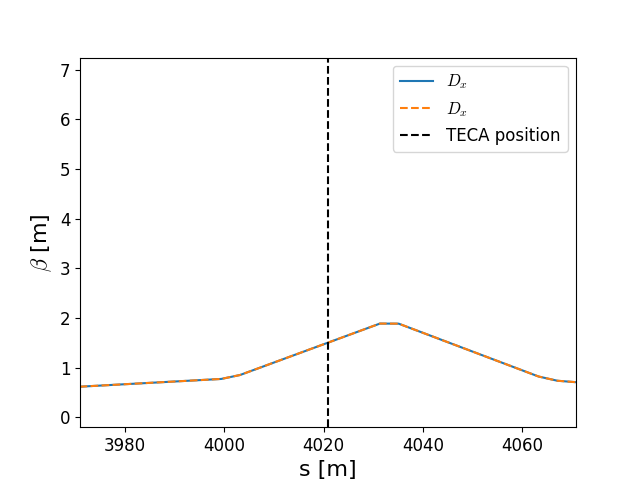

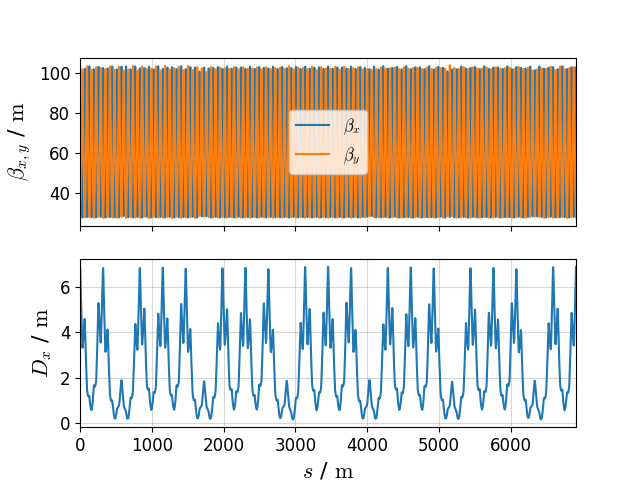

In [9]:
tw = line.twiss(method='4d')
print(tw)

xplt.TwissPlot(tw, kind='bet, dx')
# Limit the plot in the x range close to the marker of the TECA object
teca_marker_position = line.get_table()['s', 'TECA.entry']
x_range = (teca_marker_position - 50, teca_marker_position + 50)


fig, ax = plt.subplots()
#ax.plot(tw['s'], tw['betx'], label=r'$\beta_x$')
#ax.plot(tw['s'], tw['bety'], label=r'$\beta_y$')
ax.plot(tw['s'], tw['dx'], label=r'$D_x$')
ax.plot(tw_init['s'], tw_init['dx'], label=r'$D_x$', linestyle='--')
ax.axvline(teca_marker_position, color='k', linestyle='--', label='TECA position')
ax.set_xlim(x_range)
ax.set_xlabel('s [m]')
ax.set_ylabel(r'$\beta$ [m]')
ax.legend(loc='upper left')
ax.legend()
plt.show()

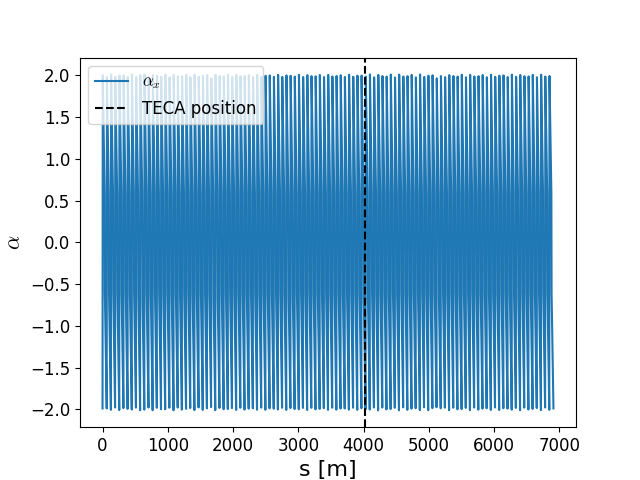

In [10]:
# Plot the alpha parameter at the TECA location
fig, ax = plt.subplots()
ax.plot(tw['s'], tw['alfx'], label=r'$\alpha_x$')
ax.axvline(teca_marker_position, color='k', linestyle='--', label='TECA position')
#ax.set_xlim(x_range)
ax.set_xlabel('s [m]')
ax.set_ylabel(r'$\alpha$')
ax.legend(loc='upper left')
plt.show()

## Phase advance between TECA and collimators

In [11]:
# Get the positions of the TECA and TPST markers
teca_position = line.get_table()['s', 'TECA.entry']
tpst_position = line.get_table()['s', 'tpst.21760_entry']

# Get the phase advances at the positions of the TECA and TPST markers
mu_x_teca = tw['mux'][tw['name'] == 'TECA.entry'][0]
mu_y_teca = tw['muy'][tw['name'] == 'TECA.entry'][0]
mu_x_tpst = tw['mux'][tw['name'] == 'tpst.21760_entry'][0]
mu_y_tpst = tw['muy'][tw['name'] == 'tpst.21760_entry'][0]

# Calculate the phase advance between the TECA and TPST markers
delta_mu_x = mu_x_tpst - mu_x_teca
delta_mu_y = mu_y_tpst - mu_y_teca

print(f"Phase advance in x between TECA and TPST (in µ terms): {delta_mu_x} π")
print(f"Phase advance in y between TECA and TPST (in µ terms): {delta_mu_y} π")

Phase advance in x between TECA and TPST (in µ terms): -7.389973894413427 π
Phase advance in y between TECA and TPST (in µ terms): -7.409741267411871 π


In [12]:
# Get the position of the TCSM marker
tcsm_position = line.get_table()['s', 'tcsm.51932.']

# Get the phase advances at the positions of the TECA and TCSM markers
mu_x_tcsm = tw['mux'][tw['name'] == 'tcsm.51932.'][0]
mu_y_tcsm = tw['muy'][tw['name'] == 'tcsm.51932.'][0]

# Calculate the phase advance between the TECA and TCSM markers
delta_mu_x_tcsm = mu_x_tcsm - mu_x_teca
delta_mu_y_tcsm = mu_y_tcsm - mu_y_teca


print(f"Phase advance in x between TECA and TCSM (in µ terms): {delta_mu_x_tcsm} π")
print(f"Phase advance in y between TECA and TCSM (in µ terms): {delta_mu_y_tcsm} π")

Phase advance in x between TECA and TCSM (in µ terms): 3.828178103436887 π
Phase advance in y between TECA and TCSM (in µ terms): 3.858904220875557 π


# Computing delta_x at the tpst

In [13]:
# TECA DEFINITION

TECA = xc.EverestCrystal(
    length=2e-3, 
    material=xc.materials.SiliconCrystal, 
    bending_angle = 174e-6 ,
    side="left",
    lattice="strip",
    jaw = - 51.4e-3,
    tilt = - 1.23e-3,
    width = 1.8e-3,
    height = 50e-3
    )

This was my way of doing it


In [14]:
# Extract the necessary parameters from the twiss table
beta_tpst = tw['betx'][tw['name'] == 'tpst.21760_entry'][0]
beta_teca = tw['betx'][tw['name'] == 'TECA.entry'][0]
alpha_teca = tw['alfx'][tw['name'] == 'TECA.entry'][0]
# Compute the dispersion at the TECA
dispersion_teca = tw['dx'][tw['name'] == 'TECA.entry'][0]
# Compute the dispersion at the TPST
dispersion_tpst = tw['dx'][tw['name'] == 'tpst.21760_entry'][0]
print(f"Dispersion at TPST: {dispersion_tpst}")
print(f"Dispersion at TECA: {dispersion_teca}")
# Compute the horizontal dispersion derivative at TECA
dpx_teca = tw['dpx'][tw['name'] == 'TECA.entry'][0]
print(f"dpx at TECA: {dpx_teca}")
# Compute the alpha twiss parameter at TECA
alpha_teca = tw['alfx'][tw['name'] == 'TECA.entry'][0]
print(f"Alpha at TECA: {alpha_teca}")
# Compute gamma at TECA
gamma_teca = (1 + alpha_teca**2) / beta_teca
print(f"Gamma at TECA: {gamma_teca}")

# Given values
x_teca = TECA.jaw  
delta_x_teca_prime = TECA.tilt + TECA.bending_angle  # Example value for delta x' at TECA

# Calculate the phase advance between TECA and TPST markers
delta_mu_x = mu_x_tpst - mu_x_teca

# Calculate x at TPST using the given equation
x_tpst = np.sqrt(beta_tpst / beta_teca) * (np.cos(delta_mu_x * np.pi) + alpha_teca * np.sin(delta_mu_x * np.pi)) * x_teca + np.sqrt(beta_teca * beta_tpst) * np.sin(delta_mu_x * np.pi) * delta_x_teca_prime



print(f"x at TPST: {x_tpst}")

Dispersion at TPST: 1.2859275849678355
Dispersion at TECA: 1.5015111937295331
dpx at TECA: 0.03671523408575077
Alpha at TECA: -1.4851974356823707
Gamma at TECA: 0.049062996818698905
x at TPST: 0.02182394847643828


Let's benchmark it with Aleksandr's method

In [15]:
# INTERNAL PART OF THE CRYSTAL RESPECT TO X AXIS
dEX = 2 * alpha_teca *(TECA.jaw-dispersion_teca*deltaP_P) * TECA.bending_angle + beta_teca*TECA.bending_angle * TECA.bending_angle + 2*beta_teca *(TECA.tilt - dpx_teca*deltaP_P)*TECA.bending_angle
E = gamma_teca * (TECA.jaw -dispersion_teca*deltaP_P)*(TECA.jaw -dispersion_teca*deltaP_P) +2 * alpha_teca * (TECA.jaw -dispersion_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P) + beta_teca * (TECA.tilt - dpx_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P)

# EXTERNAL PART OF THE CRYSTAL RESPECT TO X AXIS
dEXedge = 2 * alpha_teca *(TECA.jaw + TECA.width - dispersion_teca*deltaP_P) * TECA.bending_angle + beta_teca * TECA.bending_angle * TECA.bending_angle + 2 * beta_teca * (TECA.tilt - dpx_teca*deltaP_P)*TECA.bending_angle
Eedge = gamma_teca * (TECA.jaw + TECA.width - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width -dispersion_teca*deltaP_P) +2 * alpha_teca * (TECA.jaw + TECA.width -dispersion_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P) + beta_teca * (TECA.tilt - dpx_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P)

# MIDDLE PART OF THE CRYSTAL RESPECT TO X AXIS
dEXmiddle = 2 * alpha_teca *(TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P) * TECA.bending_angle + beta_teca * TECA.bending_angle * TECA.bending_angle + 2 * beta_teca * (TECA.tilt - dpx_teca*deltaP_P)*TECA.bending_angle
Emiddle = gamma_teca * (TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width/2 -dispersion_teca*deltaP_P) +2 * alpha_teca * (TECA.jaw + TECA.width/2 -dispersion_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P) + beta_teca * (TECA.tilt - dpx_teca*deltaP_P) * (TECA.tilt - dpx_teca*deltaP_P)


print(f"E after TECA channeling:{E} +- {dEX}")
print(f"E after TECA channeling at the exterior edge of the crystal:{Eedge} +- {dEXedge}")
print(f"E after TECA channeling at the middle of the crystal:{Emiddle} +- {dEXmiddle}")

x_channeledTPST_positive = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)+np.sqrt((beta_teca*(E+dEX))/((TECA.jaw-dispersion_teca*deltaP_P)*(TECA.jaw-dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw-dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P
x_channeledTPST_negative = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)-np.sqrt((beta_teca*(E+dEX))/((TECA.jaw-dispersion_teca*deltaP_P)*(TECA.jaw-dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw-dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P

x_channeledTPST_positiveEdge = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)+np.sqrt((beta_teca*(Eedge+dEXedge))/((TECA.jaw + TECA.width - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width - dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw + TECA.width - dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P
x_channeledTPST_negativeEdge = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)-np.sqrt((beta_teca*(Eedge+dEXedge))/((TECA.jaw + TECA.width - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width - dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw + TECA.width - dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P

x_channeledTPST_positiveMiddle = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)+np.sqrt((beta_teca*(Emiddle+dEXmiddle))/((TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P
x_channeledTPST_negativeMiddle = np.sqrt(beta_tpst/beta_teca)*(np.cos(delta_mu_x * np.pi)-np.sqrt((beta_teca*(Emiddle+dEXmiddle))/((TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P)*(TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P))-1)*np.sin(delta_mu_x * np.pi))*(TECA.jaw + TECA.width/2 - dispersion_teca*deltaP_P)+dispersion_tpst*deltaP_P


print(f"Horizontal displacement at the collimator after channeling(positive): {x_channeledTPST_positive}")
print(f"Horizontal displacement at the collimator after channeling(negative): {x_channeledTPST_negative}")


print(f"Horizontal displacement at the collimator after channeling on the exterior edge(positive): {x_channeledTPST_positiveEdge}")
print(f"Horizontal displacement at the collimator after channeling on the exterior edge(negative): {x_channeledTPST_negativeEdge}")


print(f"Horizontal displacement at the collimator after channeling from the middle(positive): {x_channeledTPST_positiveMiddle}")
print(f"Horizontal displacement at the collimator after channeling from the middle: {x_channeledTPST_negativeMiddle}")


E after TECA channeling:4.3100239720893124e-05 +- 5.17040558902159e-07
E after TECA channeling at the exterior edge of the crystal:4.068813978179153e-05 +- -4.132871148092777e-07
E after TECA channeling at the middle of the crystal:4.185444872391917e-05 +- 5.187672204644232e-08
Horizontal displacement at the collimator after channeling(positive): 0.011316138439960429
Horizontal displacement at the collimator after channeling(negative): 0.023423742435115108
Horizontal displacement at the collimator after channeling on the exterior edge(positive): 0.013025926543950777
Horizontal displacement at the collimator after channeling on the exterior edge(negative): 0.020619421396948112
Horizontal displacement at the collimator after channeling from the middle(positive): 0.012171032491955605
Horizontal displacement at the collimator after channeling from the middle: 0.02202158191603161


In [16]:
(beta_teca*(EX+dEX))/((TECA.jaw-dispersion_teca*deltaP_P)*(TECA.jaw-dispersion_teca*deltaP_P))

np.float64(0.012619475983946643)

# Calculating the $\Delta X_{col}$ for the TPST

In [17]:
delta_Xcol = 1/2 * np.sqrt(beta_tpst/beta_teca) * (beta_teca * np.sin(delta_mu_x * np.pi) * dEX)/ ((TECA.jaw -dispersion_teca*deltaP_P)*np.sqrt((beta_teca * E)/((TECA.jaw -dispersion_teca*deltaP_P)*(TECA.jaw -dispersion_teca*deltaP_P))-1))

print(f"$\Delta X_{{col}}$ is equal to {delta_Xcol}")

$\Delta X_{col}$ is equal to -0.003396479519182849


# Redoing the same but for the TCSM

In [18]:
# Get the positions of the TCSM markers
tcsm_position = line.get_table()['s', 'tcsm.51932.']

# Get the phase advances at the positions of the  TCSM markers
mu_x_tcsm = tw['mux'][tw['name'] == 'tcsm.51932.'][0]
mu_y_tcsm = tw['muy'][tw['name'] == 'tcsm.51932.'][0]

# Calculate the phase advance between the TCSM markers
delta_mu_x_tcsm = mu_x_tcsm - mu_x_teca
delta_mu_y_tcsm = mu_y_tcsm - mu_y_teca

print(f"Phase advance in x between TCSM (in µ terms): {delta_mu_x_tcsm} π")
print(f"Phase advance in y between TCSM (in µ terms): {delta_mu_y_tcsm} π")


Phase advance in x between TCSM (in µ terms): 3.828178103436887 π
Phase advance in y between TCSM (in µ terms): 3.858904220875557 π


In [19]:

# Extract the necessary parameters from the twiss table
beta_tcsm = tw['betx'][tw['name'] == 'tcsm.51932.'][0]
alpha_tcsm = tw['alfx'][tw['name'] == 'tcsm.51932.'][0]
dispersion_tcsm = tw['dx'][tw['name'] == 'tcsm.51932.'][0]
dpx_tcsm = tw['dpx'][tw['name'] == 'tcsm.51932.'][0]
gamma_tcsm = (1 + alpha_tcsm**2) / beta_tcsm


# Calculate Ex at TCSM using the given equation
dEX_tcsm = 2 * alpha_teca * (TECA.jaw - dispersion_teca * deltaP_P) * TECA.bending_angle + beta_teca * TECA.bending_angle * TECA.bending_angle + 2 * beta_teca * (TECA.tilt - dpx_teca * deltaP_P) * TECA.bending_angle
E_tcsm = gamma_teca * (TECA.jaw - dispersion_teca * deltaP_P) * (TECA.jaw - dispersion_teca * deltaP_P) + 2 * alpha_teca * (TECA.jaw - dispersion_teca * deltaP_P) * (TECA.tilt - dpx_teca * deltaP_P) + beta_teca * (TECA.tilt - dpx_teca * deltaP_P) * (TECA.tilt - dpx_teca * deltaP_P)

# Calculate Ex but on the other side of the crystal
dEXedge_tcsm = 2 * alpha_teca * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) * TECA.bending_angle + beta_teca * TECA.bending_angle * TECA.bending_angle + 2 * beta_teca * (TECA.tilt - dpx_teca * deltaP_P) * TECA.bending_angle
Eedge_tcsm = gamma_teca * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) + 2 * alpha_teca * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) * (TECA.tilt - dpx_teca * deltaP_P) + beta_teca * (TECA.tilt - dpx_teca * deltaP_P) * (TECA.tilt - dpx_teca * deltaP_P)



x_channeledTCSM_positive = np.sqrt(beta_tcsm / beta_teca) * (np.cos(delta_mu_x_tcsm * np.pi) + np.sqrt((beta_teca * (E_tcsm + dEX_tcsm)) / ((TECA.jaw - dispersion_teca * deltaP_P) * (TECA.jaw - dispersion_teca * deltaP_P)) - 1) * np.sin(delta_mu_x_tcsm * np.pi)) * (TECA.jaw - dispersion_teca * deltaP_P) + dispersion_tcsm * deltaP_P
x_channeledTCSM_negative = np.sqrt(beta_tcsm / beta_teca) * (np.cos(delta_mu_x_tcsm * np.pi) - np.sqrt((beta_teca * (E_tcsm + dEX_tcsm)) / ((TECA.jaw - dispersion_teca * deltaP_P) * (TECA.jaw - dispersion_teca * deltaP_P)) - 1) * np.sin(delta_mu_x_tcsm * np.pi)) * (TECA.jaw - dispersion_teca * deltaP_P) + dispersion_tcsm * deltaP_P

#Considering the other edge of the crystal:
x_channeledTCSM_positive_edge = np.sqrt(beta_tcsm / beta_teca) * (np.cos(delta_mu_x_tcsm * np.pi) + np.sqrt((beta_teca * (Eedge_tcsm + dEXedge_tcsm)) / ((TECA.jaw + TECA.width - dispersion_teca * deltaP_P) * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P)) - 1) * np.sin(delta_mu_x_tcsm * np.pi)) * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) + dispersion_tcsm * deltaP_P
x_channeledTCSM_negative_edge = np.sqrt(beta_tcsm / beta_teca) * (np.cos(delta_mu_x_tcsm * np.pi) - np.sqrt((beta_teca * (Eedge_tcsm + dEXedge_tcsm)) / ((TECA.jaw + TECA.width - dispersion_teca * deltaP_P) * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P)) - 1) * np.sin(delta_mu_x_tcsm * np.pi)) * (TECA.jaw + TECA.width - dispersion_teca * deltaP_P) + dispersion_tcsm * deltaP_P


print(f"E after TECA channeling for TCSM: {E_tcsm} +- {dEX_tcsm}")
print(f"Horizontal displacement at the collimator after channeling to TCSM (positive): {x_channeledTCSM_positive}")
print(f"Horizontal displacement at the collimator after channeling to TCSM (negative): {x_channeledTCSM_negative}")
print(f"Horizontal displacement at the collimator after channeling on the external part of the crystal to TCSM (positive): {x_channeledTCSM_positive_edge}")
print(f"Horizontal displacement at the collimator after channeling on the external part of the crystal to TCSM (negative): {x_channeledTCSM_negative_edge}")







E after TECA channeling for TCSM: 4.3100239720893124e-05 +- 5.17040558902159e-07
Horizontal displacement at the collimator after channeling to TCSM (positive): -0.027017355806455187
Horizontal displacement at the collimator after channeling to TCSM (negative): -0.03191684588273668
Horizontal displacement at the collimator after channeling on the external part of the crystal to TCSM (positive): -0.026904304813464872
Horizontal displacement at the collimator after channeling on the external part of the crystal to TCSM (negative): -0.029977105401545197


In [20]:
delta_Xcol_tcsm = 1/2 * np.sqrt(beta_tcsm / beta_teca) * (beta_teca * np.sin(delta_mu_x_tcsm * np.pi) * dEX_tcsm) / ((TECA.jaw - dispersion_teca * deltaP_P) * np.sqrt((beta_teca * E_tcsm) / ((TECA.jaw - dispersion_teca * deltaP_P) * (TECA.jaw - dispersion_teca * deltaP_P)) - 1))

print(f"$\Delta X_{{col}}$ for TCSM is equal to {delta_Xcol_tcsm}")

$\Delta X_{col}$ for TCSM is equal to 0.0013744269886254315


## Checking a simple case

In [21]:
Delta_xCol_tpst  = np.sqrt(beta_teca*beta_tpst)*np.sin(delta_mu_x*np.pi)*TECA.bending_angle
print(f"$\DeltaX_{{col}}$ for tpst is equal to {Delta_xCol_tpst}")

$\DeltaX_{col}$ for tpst is equal to 0.009598834687567387
